In [1]:
import sys
import os
from pathlib import Path

# Make the repo root the working directory so relative paths resolve from there.
repo_root = Path.cwd().resolve()
if repo_root.name == "analysis_notebooks":
    repo_root = repo_root.parent
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

import xarray as xr
import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns
import numpy as np
from mpl_toolkits.basemap import Basemap
import geopandas as gpd
from esda.moran import Moran
from libpysal.weights import KNN
from eval.metrics import *
from eval.plot import *
import data.valid_crd as valid_crd
import glob
import os
import yaml
import data.helper as helper
from matplotlib.colors import ListedColormap
import math
import scipy.stats as stats
import statsmodels.api as sm
from collections import defaultdict

In [3]:
test_period = [2001, 2014]

base_dir = 'outputs/Final_repeat_nowghtdecay_5b/jobs_LOCAspatioTempConv1d'



exps = ['5fcf8609', '5fe5fe59', '835d522f', '38765d44', 'f6118645', '045f73d3'] #Final Repeat nowghtdecay, 5b
testep = [10, 10, 30, 20, 30, 10]


save_path = f'plot_results'
os.makedirs(save_path, exist_ok=True)

def load_model_run(run_id, test_period, epoch=None, base_dir=base_dir):

    run_path = helper.load_run_path(run_id, base_dir)

    flat_dir = os.path.join(run_path, f"{test_period[0]}_{test_period[1]}")

    future_path = os.path.join(run_path, "ssp5_8_5_2075_2099")

    # Check which structure exists
    data_path = flat_dir
    config_path = os.path.join(run_path, 'train_config.yaml')

    x = torch.load(os.path.join(data_path, 'x.pt'), map_location='cpu', weights_only=True).squeeze(-1).numpy()
    x[x<0.254] = 0
    y = torch.load(os.path.join(data_path, 'y.pt'), map_location='cpu', weights_only=True).squeeze(-1).numpy()
    y[y<0.254] = 0
    time = torch.load(os.path.join(data_path, 'time.pt'), map_location='cpu', weights_only=False)

    xt = None
    if epoch is not None:
        xt_path = os.path.join(data_path, f'ep{epoch}', 'xt.pt')
        if os.path.exists(xt_path):
            xt = torch.load(xt_path, map_location='cpu', weights_only=False)
        else:
            print(xt_path, "does not exist.")
            print(run_id)
        xt[xt<0.254] = 0

    

    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    return {
        'run_path': run_path,
        'x': x,
        'y': y,
        'time': time,
        'xt': xt,
        'config': config
    }

models = []
for i in range(len(exps)):
    model = load_model_run(exps[i], test_period, epoch=testep[i])
    models.append(model)

In [5]:
valid_coords = []
loca_all = []
QM_all = []
ISIMIP_all = []
ECDFM_all = []
LS_all = []
QDM_all = []
SDM_all = []




for i in range(len(models)):
    
    cmip6_dir = models[i]['config']['cmip_dir']
    clim = models[i]['config']['clim']
    ref = models[i]['config']['ref']
    train_period = [models[i]['config']['train_start'], models[i]['config']['train_end']]
    future_period = [2015,2099]


    ds_sample = xr.open_dataset(f"{cmip6_dir}/{clim}/historical/precipitation/clipped_US.nc")

    shapefile_path = None if not  models[i]['config']['spatial_test']  else models[i]['config']['shapefile_filter_path']
    
    try:
        spatial_extent = models[i]['config']['spatial_extent_test']
    except:
        spatial_extent = models[i]['config']['spatial_extent_val']

    valid_coords.append(valid_crd.valid_lat_lon(ds_sample, var_name='pr', shapefile_path=shapefile_path, attrList=spatial_extent))


    #loading loca

    loca = xr.open_dataset(f'{cmip6_dir}/{clim}/historical/precipitation/loca/coarse_USclip.nc')
    loca = loca['pr'].sel(lat=xr.DataArray(valid_coords[i][:, 0], dims='points'),
                                        lon=xr.DataArray(valid_coords[i][:, 1], dims='points'),
                                        method='nearest')
    loca = loca.sel(time =slice(f'{test_period[0]}', f'{test_period[1]}')).values

    #unit conversion
    loca_all.append(loca*86400)



    # if 'QM' in method_names:
    QM_bench = f'benchmark/QuantileMapping/conus/{clim}-{ref}/{train_period}_historical_{test_period}.pt'
    QM_debiased = torch.load(QM_bench, weights_only=False).squeeze(-1)
    QM_all.append(QM_debiased*86400)

    # if 'QM' in method_names:
    ISIMIP_bench = f'benchmark/ISIMIP/conus/{clim}-{ref}/{train_period}_historical_{test_period}.pt'
    ISIMIP_debiased = torch.load(ISIMIP_bench, weights_only=False).squeeze(-1)
    ISIMIP_all.append(ISIMIP_debiased*86400)

    ECDFM_bench = f'benchmark/ECDFM/conus/{clim}-{ref}/{train_period}_historical_{test_period}.pt'
    ECDFM_debiased = torch.load(ECDFM_bench, weights_only=False).squeeze(-1)
    ECDFM_all.append(ECDFM_debiased*86400) 



    QDM_bench = f'benchmark/QuantileDeltaMapping/conus/{clim}-{ref}/{train_period}_historical_{test_period}.pt'
    QDM_debiased = torch.load(QDM_bench, weights_only=False).squeeze(-1)
    QDM_all.append(QDM_debiased*86400)


In [6]:
## this block filters 'y' based on 'x' calender
counter = 0
for model in models:
    time = model['time']
    
    x_time_np = np.array([pd.Timestamp(str(t)) for t in time])
    x_time_np = np.array([pd.Timestamp(t).replace(hour=0, minute=0, second=0) for t in x_time_np], dtype='datetime64[D]')
    # Generate a daily time array following the standard Gregorian calendar
    y_time = pd.date_range(start=f"{test_period[0]}-01-01", end=f"{test_period[1]}-12-31", freq="D")

    # Convert to NumPy array for indexing and comparison
    y_time_np = y_time.to_numpy()

    # Find indices where observed time matches model time
    matched_indices = np.where(np.isin(y_time_np, x_time_np))[0]

    model['y'] = model['y'][matched_indices,:]
    model['x_time_np'] = x_time_np

    loca_all[counter] = loca_all[counter][matched_indices, :]

  

    counter+=1







In [7]:
# cities =  {'Phoenix': [33.431, -112.008],
#  'Boulder': [39.998, -105.268],
#  'Ft Logan': [46.543, -110.902],
#  'Sioux City': [42.387, -96.369],
#  'Yosemite': [37.749, -119.590],
#  'ARM site': [36.608, -97.488],
#  'Seattle': [47.545, -122.243],
#  'Pittsburgh': [40.437, -80.079],
#  'Orlando': [28.450, -81.741],
#  'Birmingham': [33.568, -86.751]}

cities =  {'Phoenix': [33.431, -112.008],
 'Yosemite': [37.749, -119.590],
 'Seattle': [47.545, -122.243],
 'Orlando': [28.450, -81.741],
 'Philadelphia': [39.953, -75.165]
}
# Convert to array
city_names = list(cities.keys())
city_coords = np.array(list(cities.values()))  # shape (10, 2)

# Assuming valid_coords is already loaded as a numpy array (lat, lon)
# Compute distances between each city and all valid_coords
def find_nearest_indices(city_coords, valid_coords):
    nearest_indices = []
    nearest_coords = []

    for coord in city_coords:
        # Broadcasting subtraction
        dists = np.linalg.norm(valid_coords - coord, axis=1)
        idx = np.argmin(dists)
        nearest_indices.append(idx)
        nearest_coords.append(valid_coords[idx])

    return nearest_indices, np.array(nearest_coords)

# Call the function
city_index = []
for coords in valid_coords:
    city_index.append(find_nearest_indices(city_coords, coords))

In [8]:
quantiles = np.arange(0.01, 1.00, 0.01)

quantile_x_local = []
quantile_xt_local = []
quantile_y_local = []
quantile_loca_local = []
quantile_QM_local = []
quantile_ISIMIP_local = []
quantile_ECDFM_local = []
quantile_QDM_local = []

for i in range(len(cities)):
    quantile_total_x = []
    quantile_total_y = []
    quantile_total_xt = []
    quantile_total_loca = []
    quantile_total_QM = []
    quantile_total_ISIMIP = []
    quantile_total_ECDFM = []
    quantile_total_QDM = []

    for j in range(len(models)):
        loc = city_index[j][0][i]

        quantile_total_x.append(np.nanquantile(models[j]['x'], quantiles, axis=0)[:,loc])
        quantile_total_y.append(np.nanquantile(models[j]['y'], quantiles, axis=0)[:,loc])
        quantile_total_xt.append(np.nanquantile(models[j]['xt'], quantiles, axis=0)[:,loc])
        quantile_total_loca.append(np.nanquantile(loca_all[j], quantiles, axis=0)[:,loc])
        quantile_total_QM.append(np.nanquantile(QM_all[j], quantiles, axis=0)[:,loc])

        quantile_total_ISIMIP.append(np.nanquantile(ISIMIP_all[j], quantiles, axis=0)[:,loc])
        quantile_total_ECDFM.append(np.nanquantile(ECDFM_all[j], quantiles, axis=0)[:,loc])
        quantile_total_QDM.append(np.nanquantile(QDM_all[j], quantiles, axis=0)[:,loc])


    quantile_x_local.append(np.array(quantile_total_x).T)
    quantile_xt_local.append(np.array(quantile_total_xt).T)
    quantile_y_local.append(np.array(quantile_total_y).T)
    quantile_loca_local.append(np.array(quantile_total_loca).T)
    quantile_QM_local.append(np.array(quantile_total_QM).T)

    quantile_ISIMIP_local.append(np.array(quantile_total_ISIMIP).T)
    quantile_ECDFM_local.append(np.array(quantile_total_ECDFM).T)
    quantile_QDM_local.append(np.array(quantile_total_QDM).T)


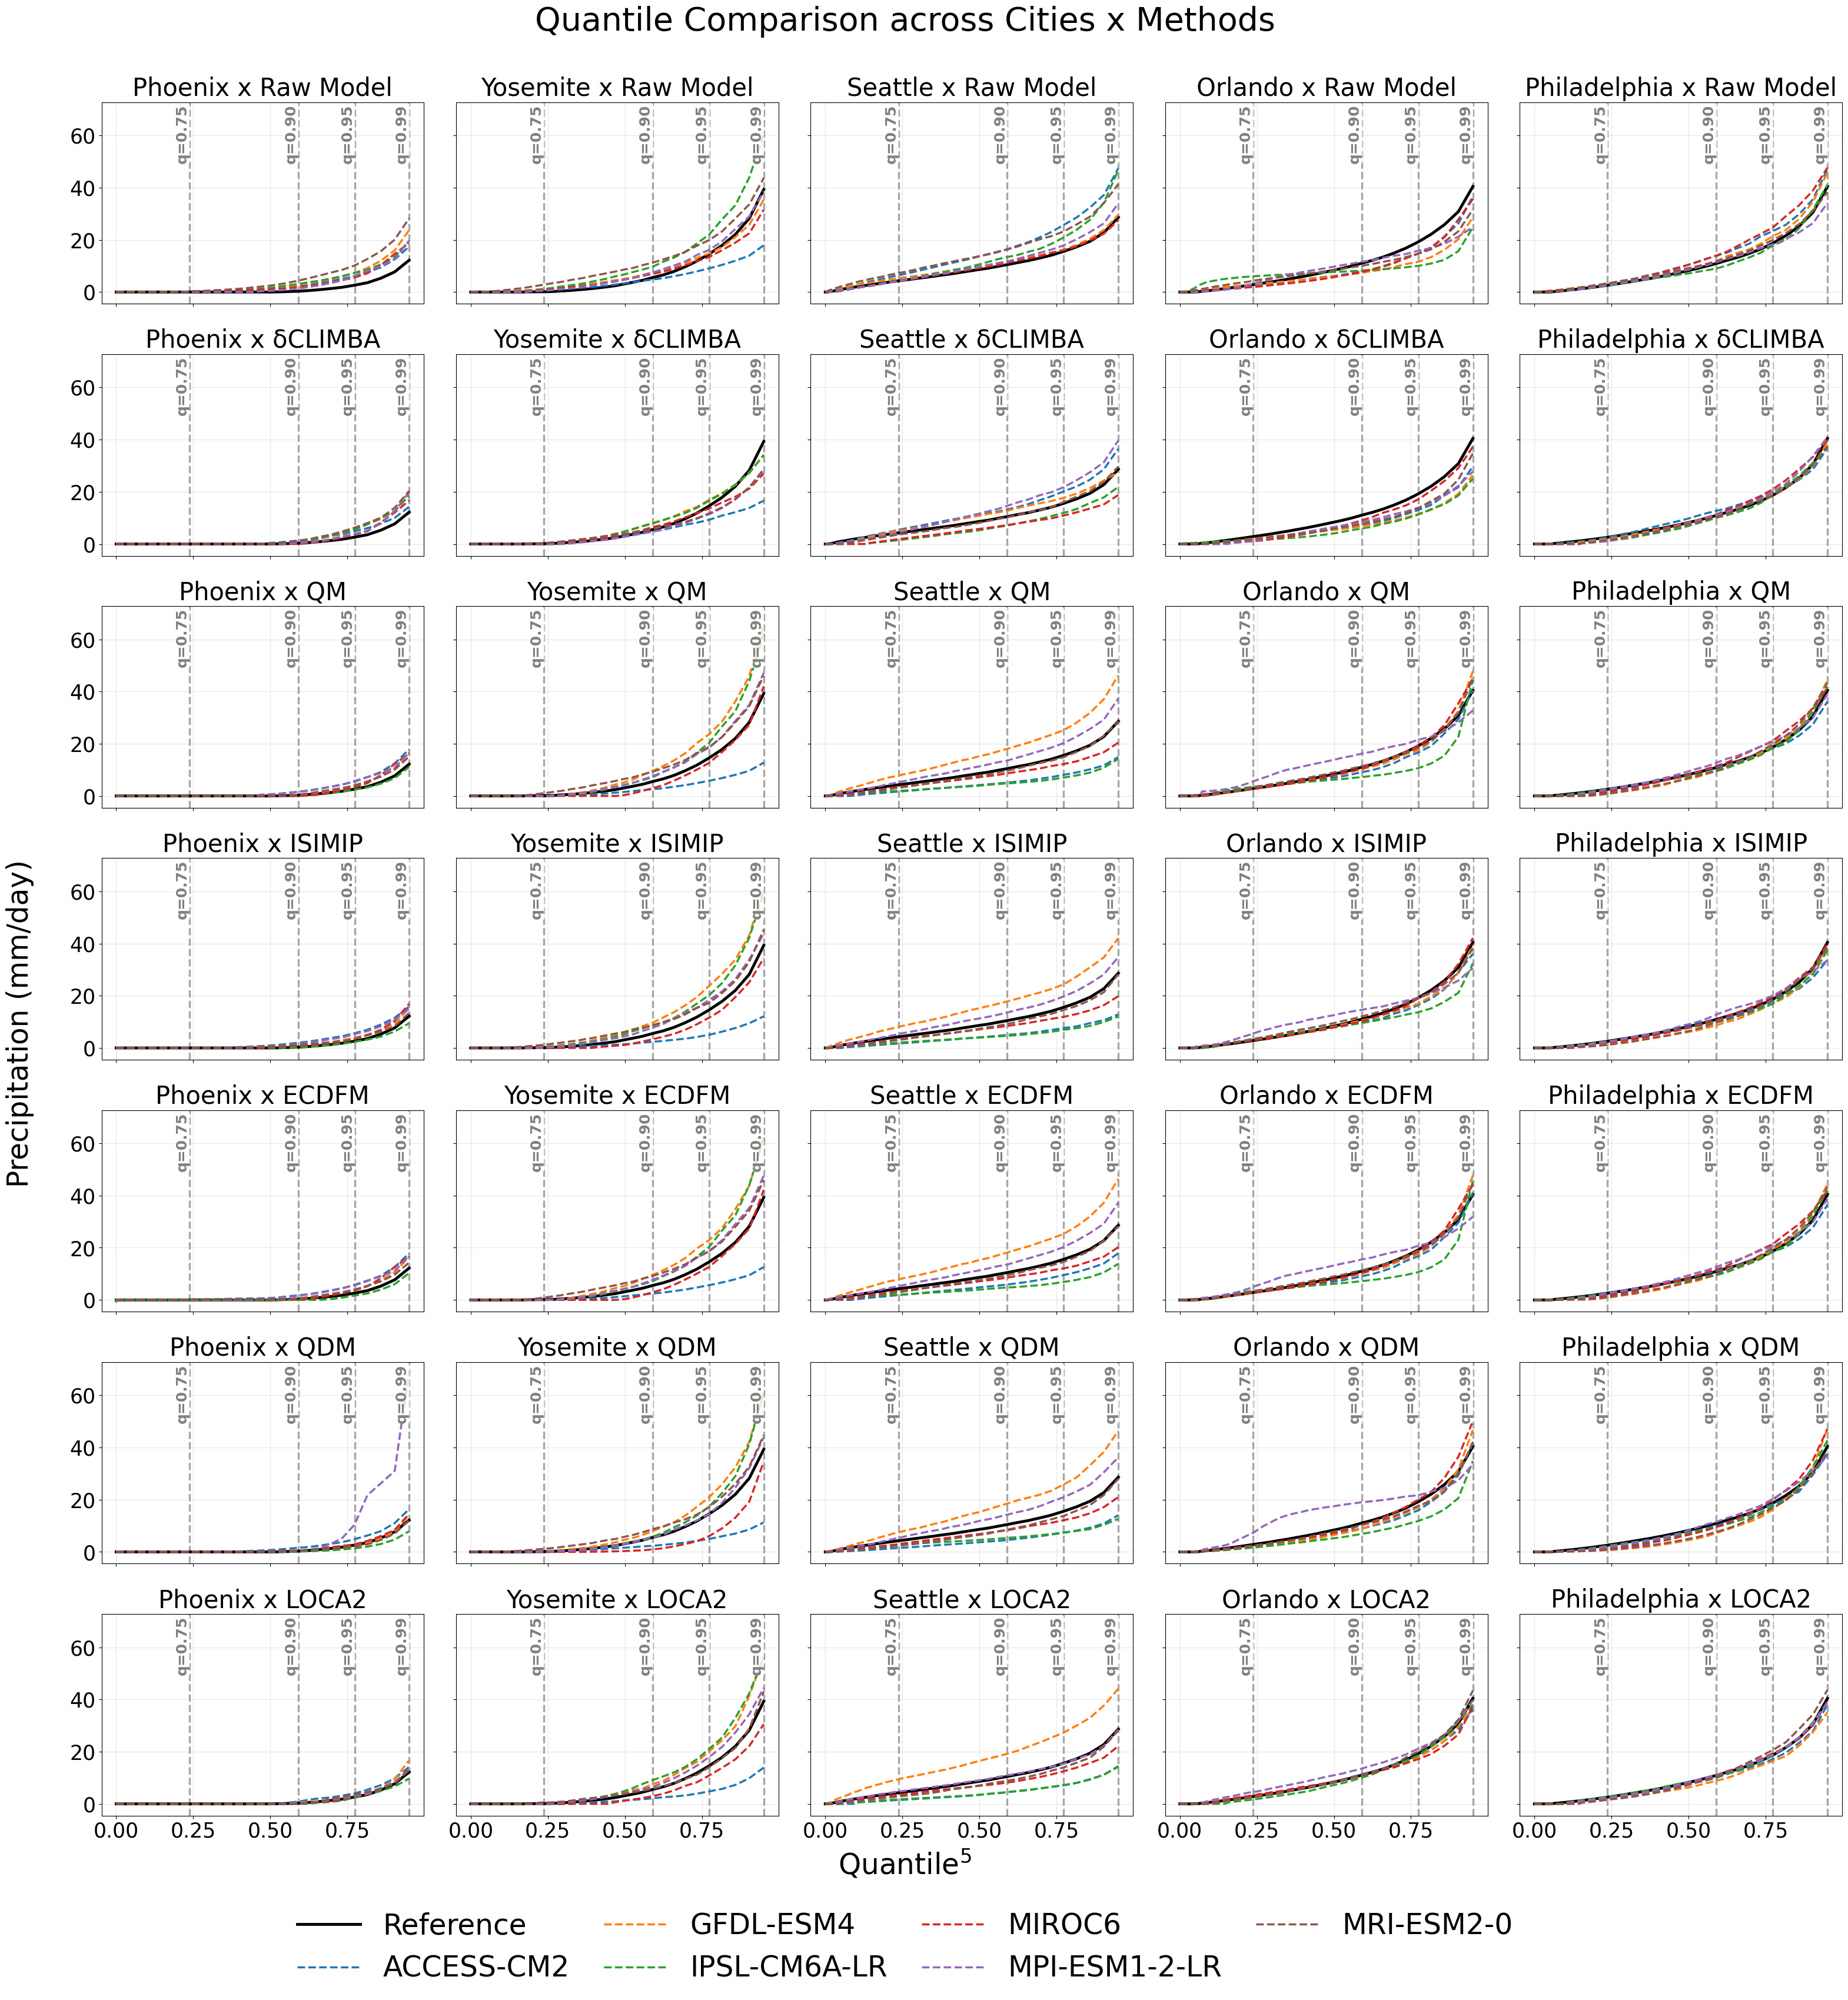

In [9]:
# cmip6_models = ['access_cm2', 'gfdl_esm4', 'ipsl_cm6a_lr', 'miroc6', 'mpi_esm1_2_lr', 'mri_esm2_0']
cmip6_models = ['ACCESS-CM2', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-LR', 'MRI-ESM2-0']

city_names = list(cities.keys())
methods = {
    "Raw Model": quantile_x_local,
    "δCLIMBA": quantile_xt_local,
    "QM": quantile_QM_local,
    "ISIMIP": quantile_ISIMIP_local,
    "ECDFM": quantile_ECDFM_local,
    "QDM": quantile_QDM_local,
    "LOCA2": quantile_loca_local,
}

n_cities = len(city_names)
n_methods = len(methods)

fig, axes = plt.subplots(
    ncols=n_cities, nrows=n_methods,
    figsize=(6.5 * n_cities, 5.2 * n_methods),
    sharex=True, sharey=True,
    constrained_layout=False
)

if n_cities == 1 and n_methods == 1:
    axes = [[axes]]
elif n_cities == 1:
    axes = [axes]
elif n_methods == 1:
    axes = [[ax] for ax in axes]

q_markers = [0.75, 0.90, 0.95, 0.99]
q_marker_x = [q**5 for q in q_markers]
q_styles = ['--', '--', '--', '--']

for i, city in enumerate(city_names):
    for j, (method_name, method_data) in enumerate(methods.items()):
        ax = axes[j][i]

        ax.plot(
            quantiles**5,
            quantile_y_local[i].mean(axis=1),
            color="black", linewidth=3.5, label="Reference"
        )

        n_models = method_data[i].shape[1]
        for m in range(n_models):
            ax.plot(
                quantiles**5,
                method_data[i][:, m],
                linestyle="--", linewidth=2.5,
                label=cmip6_models[m] if (i == 0 and j == 0) else None
            )

        # Bold vertical markers at selected quantiles with readable labels
        for q, xline, ls in zip(q_markers, q_marker_x, q_styles):
            ax.axvline(
                x=xline,
                color="grey",
                linestyle=ls,
                linewidth=2.4,
                alpha=0.7,
                zorder=1
            )
            # y_top = ax.get_ylim()[1]
            ax.text(
                xline, 0.99, f"q={q:.2f}",              # y=0.99 means near top of axes
                transform=ax.get_xaxis_transform(),     # x in data coords, y in axes coords
                rotation=90,
                va="top", ha="right",
                fontsize=18, fontweight="bold", color="grey",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.5),
                clip_on=False
            )

        ax.set_title(f"{city} x {method_name}", fontsize=30, pad=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', labelsize=25)
        ax.tick_params(axis='y', labelsize=25)

        # Show only outer tick labels to reduce clutter
        if j < n_methods - 1:
            ax.tick_params(labelbottom=False)
        if i > 0:
            ax.tick_params(labelleft=False)

# Shared labels
fig.supxlabel("Quantile$^{5}$", fontsize=35, y=0.1)
fig.supylabel("Precipitation (mm/day)", fontsize=35, x=0.03)

# Global legend placed lower, with smaller font to avoid overlap
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center", ncol=4,
    bbox_to_anchor=(0.5, 0.04),
    fontsize=35, frameon=False,
    columnspacing=1.2, handlelength=2.2
)

fig.suptitle("Quantile Comparison across Cities x Methods", fontsize=40, y=0.975)

# Reserve explicit margins so ylabel and legend do not collide
fig.subplots_adjust(left=0.08, right=0.99, top=0.93, bottom=0.13, wspace=0.1, hspace=0.25)

# plt.savefig(f"{save_path}/Quantile_Comparison_Cities_x_Methods.png", bbox_inches="tight", dpi=300)
plt.show()

## Precipitation Indices

In [10]:
from collections import defaultdict

interp_coords = []
ensemble_coords = valid_coords[2]
for coords in valid_coords:
    interp_coords.append(find_nearest_indices(ensemble_coords, coords))
    
climate_indices = ClimateIndices()

thresholds = climate_indices.get_indices()




In [10]:
x_ensemble_indices = defaultdict(list)
y_ensemble_indices = defaultdict(list)
xt_ensemble_indices = defaultdict(list)
loca_ensemble_indices = defaultdict(list)
QM_ensemble_indices = defaultdict(list)
ISIMIP_ensemble_indices = defaultdict(list)
ECDFM_ensemble_indices = defaultdict(list)
QDM_ensemble_indices = defaultdict(list)

counter = 0
for model in models:
    target_idx = interp_coords[counter][0]
    for label, (threshold, comparison) in thresholds.items():
        if callable(threshold):  # If function, apply it to each dataset
            model[f"{label}_x"] = threshold(model["x_time_np"], model["x"])
            model[f"{label}_y"] = threshold(model["x_time_np"], model["y"])
            model[f"{label}_xt"] = threshold(model["x_time_np"], model["xt"])
            model[f"{label}_loca"] = threshold(model["x_time_np"], loca_all[counter])
            model[f"{label}_QM"] = threshold(model["x_time_np"], QM_all[counter])
            model[f"{label}_ISIMIP"] = threshold(model["x_time_np"], ISIMIP_all[counter])
            model[f"{label}_ECDFM"] = threshold(model["x_time_np"], ECDFM_all[counter])
            model[f"{label}_QDM"] = threshold(model["x_time_np"], QDM_all[counter])

            x_ensemble_indices[label].append(model[f"{label}_x"][:, target_idx])
            y_ensemble_indices[label].append(model[f"{label}_y"][:, target_idx])
            xt_ensemble_indices[label].append(model[f"{label}_xt"][:, target_idx])
            loca_ensemble_indices[label].append(model[f"{label}_loca"][:, target_idx])
            QM_ensemble_indices[label].append(model[f"{label}_QM"][:, target_idx])
            ISIMIP_ensemble_indices[label].append(model[f"{label}_ISIMIP"][:, target_idx])
            ECDFM_ensemble_indices[label].append(model[f"{label}_ECDFM"][:, target_idx])
            QDM_ensemble_indices[label].append(model[f"{label}_QDM"][:, target_idx])
    counter += 1


for label in x_ensemble_indices.keys():
    x_ensemble_indices[label] = np.concatenate(x_ensemble_indices[label], axis=1)
    y_ensemble_indices[label] = np.concatenate(y_ensemble_indices[label], axis=1)
    xt_ensemble_indices[label] = np.concatenate(xt_ensemble_indices[label], axis=1)
    loca_ensemble_indices[label] = np.concatenate(loca_ensemble_indices[label], axis=1)
    QM_ensemble_indices[label] = np.concatenate(QM_ensemble_indices[label], axis=1)
    ISIMIP_ensemble_indices[label] = np.concatenate(ISIMIP_ensemble_indices[label], axis=1)
    ECDFM_ensemble_indices[label] = np.concatenate(ECDFM_ensemble_indices[label], axis=1)
    QDM_ensemble_indices[label] = np.concatenate(QDM_ensemble_indices[label], axis=1)



bias_dict = {}

for label, (threshold, comparison) in thresholds.items():
    if callable(threshold):
        xt_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[label], xt_ensemble_indices[label])
        loca_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[label], loca_ensemble_indices[label])
        QM_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[label], QM_ensemble_indices[label])
        ISIMIP_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[label], ISIMIP_ensemble_indices[label])
        ECDFM_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[label], ECDFM_ensemble_indices[label])
        QDM_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[label], QDM_ensemble_indices[label])

        bias_dict[label] = (xt_bias[0], xt_bias[1], QM_bias[1], ISIMIP_bias[1], ECDFM_bias[1], QDM_bias[1], loca_bias[1])

x_avg = np.nanmean([bias[0] for bias in bias_dict.values()], axis=0)
xt_avg = np.nanmean([bias[1] for bias in bias_dict.values()], axis=0)
QM_avg = np.nanmean([bias[2] for bias in bias_dict.values()], axis=0)
ISIMIP_avg = np.nanmean([bias[3] for bias in bias_dict.values()], axis=0)
ECDFM_avg = np.nanmean([bias[4] for bias in bias_dict.values()], axis=0)
QDM_avg = np.nanmean([bias[5] for bias in bias_dict.values()], axis=0)
loca_avg = np.nanmean([bias[6] for bias in bias_dict.values()], axis=0)

bias_dict["Average"] = (x_avg, xt_avg, QM_avg, ISIMIP_avg, ECDFM_avg, QDM_avg, loca_avg)

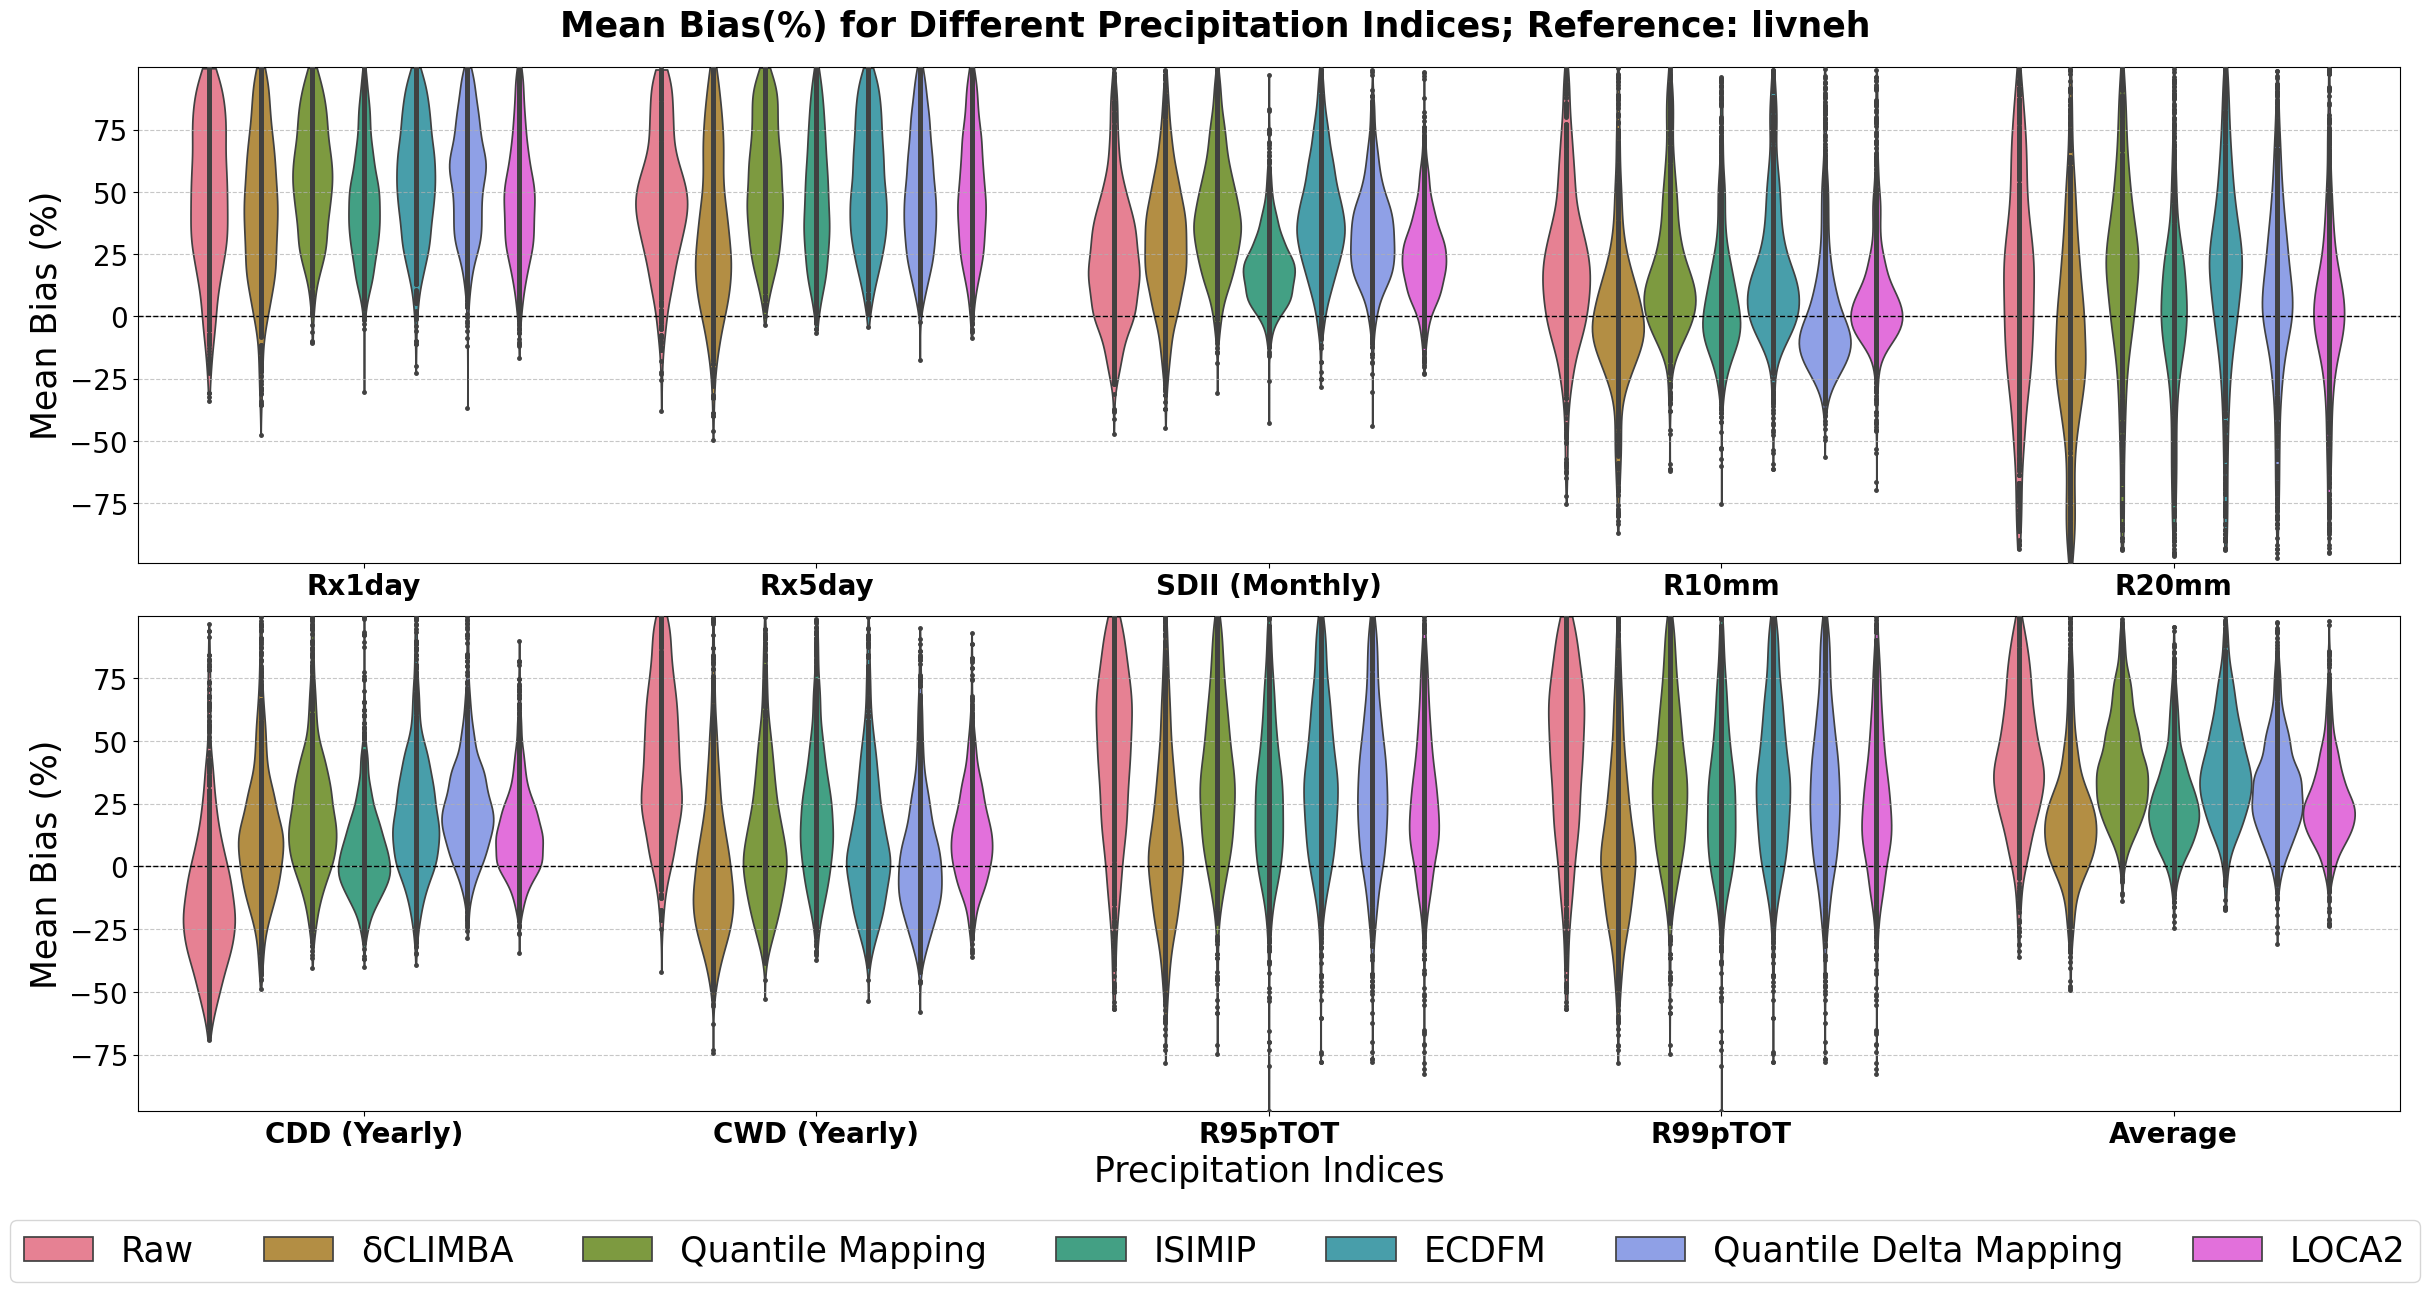

In [11]:
keys = ['SDII (Monthly)','CDD (Yearly)', 'CWD (Yearly)', "Rx1day", "Rx5day", "R10mm",  "R20mm", "R95pTOT", "R99pTOT", 'Average']
d = dict(filter(lambda item: item[0] in keys , bias_dict.items()))

# Split keys into two groups for two rows
keys_list = list(d.keys())
d1 = dict(list(d.items())[:5])  # First 5 indices
d2 = dict(list(d.items())[5:])  # Remaining indices

# Create a 2x1 subplot figure (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(24, 12))

ref_label = models[0]['config']['ref']
method_names = ['δCLIMBA','Quantile Mapping', 'ISIMIP', 'ECDFM', 
                'Quantile Delta Mapping', 'LOCA2'] 

# Call the function for each row with different data
plot_violin_bias(axes[0], d1, "Bias(%)", "",  method_names=method_names, remove_outlier=True)
axes[0].legend().remove()  # Remove legend from top plot
axes[0].set_ylabel("Mean Bias (%)", fontsize=25)
axes[0].set_xlabel("")  # Remove x-axis label from row 1
axes[0].margins(y=0)

plot_violin_bias(axes[1], d2, "Bias(%)", "",  method_names=method_names, remove_outlier=True)
axes[1].legend().remove()  # Remove legend from bottom plot
axes[1].set_xlabel("Precipitation Indices", fontsize=25)
axes[1].set_ylabel("Mean Bias (%)", fontsize=25)
axes[1].margins(y=0)
# Set same tick font size for both rows
axes[0].tick_params(axis='x', labelsize=20)
axes[0].tick_params(axis='y', labelsize=20)
axes[1].tick_params(axis='x', labelsize=20)
axes[1].tick_params(axis='y', labelsize=20)

# Add single title at the top
fig.suptitle(f"Mean Bias(%) for Different Precipitation Indices; Reference: {ref_label}", fontsize=25, fontweight="bold", y=0.995)

# Place legend as one line at bottom center
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=25, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=len(handles), frameon=True)

plt.tight_layout()
plt.savefig(f'{save_path}/violin_Pindices.png')
plt.show()

### Precipitation Indices - Ensemble

In [17]:
interp_coords = []
ensemble_coords = valid_coords[2]
for coords in valid_coords:
    interp_coords.append(find_nearest_indices(ensemble_coords, coords))

In [ ]:


# Initialize climate indices manager
climate_indices = ClimateIndices()

thresholds = climate_indices.get_indices()

x_ensemble_indices = {}
# y_ensemble_indices = {}
xt_ensemble_indices = {}
loca_ensemble_indices = {}
QM_ensemble_indices = {}
ISIMIP_ensemble_indices = {}
ECDFM_ensemble_indices = {}
LS_ensemble_indices = {}
QDM_ensemble_indices = {}
SDM_ensemble_indices = {}

counter = 0 
for model in models:

    for label, (threshold, comparison) in thresholds.items():
        if callable(threshold):  # If function, apply it to y
            model[f'{label}_x'] = threshold(model['x_time_np'], model['x'])
            model[f'{label}_y'] = threshold(model['x_time_np'], model['y'])
            model[f'{label}_xt'] = threshold(model['x_time_np'], model['xt'])
            model[f'{label}_loca'] = threshold(model['x_time_np'], loca_all[counter])
            model[f'{label}_QM'] = threshold(model['x_time_np'], QM_all[counter])
            model[f'{label}_ISIMIP'] = threshold(model['x_time_np'], ISIMIP_all[counter])
            model[f'{label}_ECDFM'] = threshold(model['x_time_np'], ECDFM_all[counter])
            model[f'{label}_QDM'] = threshold(model['x_time_np'], QDM_all[counter])

            if label not in x_ensemble_indices:
                x_ensemble_indices[label] = model[f'{label}_x'][:, interp_coords[counter][0]]/len(models)
                xt_ensemble_indices[label] = model[f'{label}_xt'][:, interp_coords[counter][0]]/len(models)
                loca_ensemble_indices[label] = model[f'{label}_loca'][:, interp_coords[counter][0]]/len(models)
                QM_ensemble_indices[label] = model[f'{label}_QM'][:, interp_coords[counter][0]]/len(models)
                ISIMIP_ensemble_indices[label] = model[f'{label}_ISIMIP'][:, interp_coords[counter][0]]/len(models)
                ECDFM_ensemble_indices[label] = model[f'{label}_ECDFM'][:, interp_coords[counter][0]]/len(models)
                QDM_ensemble_indices[label] = model[f'{label}_QDM'][:, interp_coords[counter][0]]/len(models)
            else:
                x_ensemble_indices[label]+= model[f'{label}_x'][:, interp_coords[counter][0]]/len(models)
                xt_ensemble_indices[label]+= model[f'{label}_xt'][:, interp_coords[counter][0]]/len(models)
                loca_ensemble_indices[label]+= model[f'{label}_loca'][:, interp_coords[counter][0]]/len(models)
                QM_ensemble_indices[label]+= model[f'{label}_QM'][:, interp_coords[counter][0]]/len(models)
                ISIMIP_ensemble_indices[label]+= model[f'{label}_ISIMIP'][:, interp_coords[counter][0]]/len(models)
                ECDFM_ensemble_indices[label]+= model[f'{label}_ECDFM'][:, interp_coords[counter][0]]/len(models)
                QDM_ensemble_indices[label]+= model[f'{label}_QDM'][:, interp_coords[counter][0]]/len(models)
    counter+=1
    

In [ ]:
bias_dict = {}

for label, (threshold, comparison) in thresholds.items():
    y_ensemble_indices = models[2]
    if callable(threshold):
        xt_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[f'{label}_y'], xt_ensemble_indices[label])
        loca_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[f'{label}_y'], loca_ensemble_indices[label])
        QM_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[f'{label}_y'], QM_ensemble_indices[label])
        ISIMIP_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[f'{label}_y'], ISIMIP_ensemble_indices[label])
        ECDFM_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[f'{label}_y'], ECDFM_ensemble_indices[label])
        QDM_bias = compute_mean_bias_percentage(None, x_ensemble_indices[label], y_ensemble_indices[f'{label}_y'], QDM_ensemble_indices[label])

        bias_dict[label] = (xt_bias[0], xt_bias[1], QM_bias[1], ISIMIP_bias[1], ECDFM_bias[1], QDM_bias[1], loca_bias[1])

## add another key to the bias dict, which is average of all the previous keys for xt, loca and QM
x_avg = np.nanmean([bias[0] for bias in bias_dict.values()], axis=0)
xt_avg = np.nanmean([bias[1] for bias in bias_dict.values()], axis=0)
QM_avg = np.nanmean([bias[2] for bias in bias_dict.values()], axis=0)
ISIMIP_avg = np.nanmean([bias[3] for bias in bias_dict.values()], axis=0)
ECDFM_avg = np.nanmean([bias[4] for bias in bias_dict.values()], axis=0)
QDM_avg = np.nanmean([bias[5] for bias in bias_dict.values()], axis=0)
loca_avg = np.nanmean([bias[6] for bias in bias_dict.values()], axis=0)

bias_dict['Average'] = (x_avg, xt_avg,  QM_avg, ISIMIP_avg, ECDFM_avg, QDM_avg, loca_avg)


In [21]:
def filter_bias_dict(bias_dict, method_indices=None, method_names=None):
    """
    Filter bias_dict to extract specific methods.
    
    Parameters:
    -----------
    bias_dict : dict
        Dictionary where each value is a tuple of bias arrays
    method_indices : list of int, optional
        Indices of methods to extract (e.g., [0, 1, 2, 6] for raw, dCLIMAD-BA, QM, LOCA)
    method_names : list of str, optional
        Names of methods to extract (e.g., ['Raw', 'dCLIMAD-BA', 'QM', 'LOCA'])
        
    Returns:
    --------
    filtered_dict : dict
        Dictionary with same keys but filtered tuples
    method_labels : list
        Labels for the filtered methods
    """
    # Define method name mapping
    method_map = {
        'Raw': 0,
        'dCLIMAD-BA': 1,
        'QM': 2,
        'ISIMIP': 3,
        'ECDFM': 4,
        'QDM': 5,
        'LOCA': 6
    }
    
    # If method names are provided, convert to indices
    if method_names is not None:
        method_indices = [method_map[name] for name in method_names]
    
    # Default to all methods if nothing specified
    if method_indices is None:
        method_indices = list(range(7))
    
    # Filter the dictionary
    filtered_dict = {}
    for label, bias_tuple in bias_dict.items():
        filtered_dict[label] = tuple(bias_tuple[i] for i in method_indices)
    
    # Get method labels
    reverse_map = {v: k for k, v in method_map.items()}
    method_labels = [reverse_map[i] for i in method_indices]
    
    return filtered_dict, method_labels



# Option 3: Extract only bias correction methods (no raw model)
filtered_bias_dict, labels = filter_bias_dict(bias_dict, method_names=['Raw','dCLIMAD-BA', 'LOCA', 'QM'])
print(f"Extracted methods: {labels}")

Extracted methods: ['Raw', 'dCLIMAD-BA', 'LOCA', 'QM']


In [22]:
def plot_spatial_bias(
    valid_coords,
    bias_data_dict,
    threshold_types,
    label,
    method_names=None,
    vmin=None,
    vmax=None,
    cmap="coolwarm"
):
    """
    Plots a matrix of spatial bias maps with a shared color scale.
    Rows = precipitation indices, Columns = methods.
    """
    from scipy.interpolate import griddata
    import matplotlib as mpl

    lats, lons = zip(*valid_coords)
    lats = np.array(lats)
    lons = np.array(lons)

    # Build a regular lat/lon grid for interpolation
    grid_spacing = 0.5
    grid_lat = np.arange(lats.min() - 1, lats.max() + 1, grid_spacing)
    grid_lon = np.arange(lons.min() - 1, lons.max() + 1, grid_spacing)
    grid_lons, grid_lats = np.meshgrid(grid_lon, grid_lat)

    num_rows = len(threshold_types)
    num_methods = len(next(iter(bias_data_dict.values())))

    if method_names is None:
        method_labels = [f"Method {i+1}" for i in range(num_methods)]
    else:
        method_labels = method_names

    # If limits are not given, compute global min/max across selected data
    if vmin is None or vmax is None:
        all_vals = []
        for tt in threshold_types:
            for arr in bias_data_dict[tt]:
                all_vals.append(np.ravel(arr))
        all_vals = np.concatenate(all_vals)
        all_vals = all_vals[np.isfinite(all_vals)]
        if vmin is None:
            vmin = float(np.nanmin(all_vals))
        if vmax is None:
            vmax = float(np.nanmax(all_vals))

    # Shared normalization for every panel + the colorbar
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    levels = np.linspace(vmin, vmax, 21)

    fig, axes = plt.subplots(
        num_rows,
        num_methods,
        figsize=(6 * num_methods, 3.2 * num_rows),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_2d(axes)

    for i, threshold_type in enumerate(threshold_types):
        bias_list = bias_data_dict[threshold_type]

        for j, bias in enumerate(bias_list):
            ax = axes[i, j]

            m = Basemap(
                projection="merc",
                llcrnrlat=lats.min() - 1,
                urcrnrlat=lats.max() + 1,
                llcrnrlon=lons.min() - 1,
                urcrnrlon=lons.max() + 1,
                resolution="i",
                ax=ax
            )
            m.drawcoastlines()
            m.drawcountries()

            # Interpolate to regular grid
            bias_grid = griddata(
                (lons, lats),
                bias,
                (grid_lons, grid_lats),
                method="linear",
                fill_value=np.nan
            )

            x_grid, y_grid = m(grid_lons, grid_lats)
            m.contourf(
                x_grid,
                y_grid,
                bias_grid,
                levels=levels,
                cmap=cmap,
                norm=norm,
                extend="both"
            )

            # Optional: show original points
            x_pts, y_pts = m(lons, lats)
            m.scatter(x_pts, y_pts, marker="x", color="k", s=10, alpha=0.35)

            if i == 0:
                ax.set_title(method_labels[j], fontsize=16)
            if j == 0:
                ax.text(
                    -0.05, 0.5, threshold_type,
                    va="center", ha="right",
                    transform=ax.transAxes,
                    fontsize=16, fontweight="bold", rotation=90
                )

    # Create colorbar from the exact same norm/cmap (important)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    # cbar_ax = fig.add_axes([0.88, 0.16, 0.018, 0.68])
    cbar_ax = fig.add_axes([0.87, 0.15, 0.015, 0.7])

    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(label, fontsize=16)
    cbar.ax.tick_params(labelsize=16)

    fig.suptitle("Spatial Bias Across Precipitation Indices", fontsize=30, fontweight="bold", y=0.955)
    plt.tight_layout(rect=[0, 0, 0.86, 0.95])
    plt.show()

/tmp/ipykernel_428256/742131916.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.95])


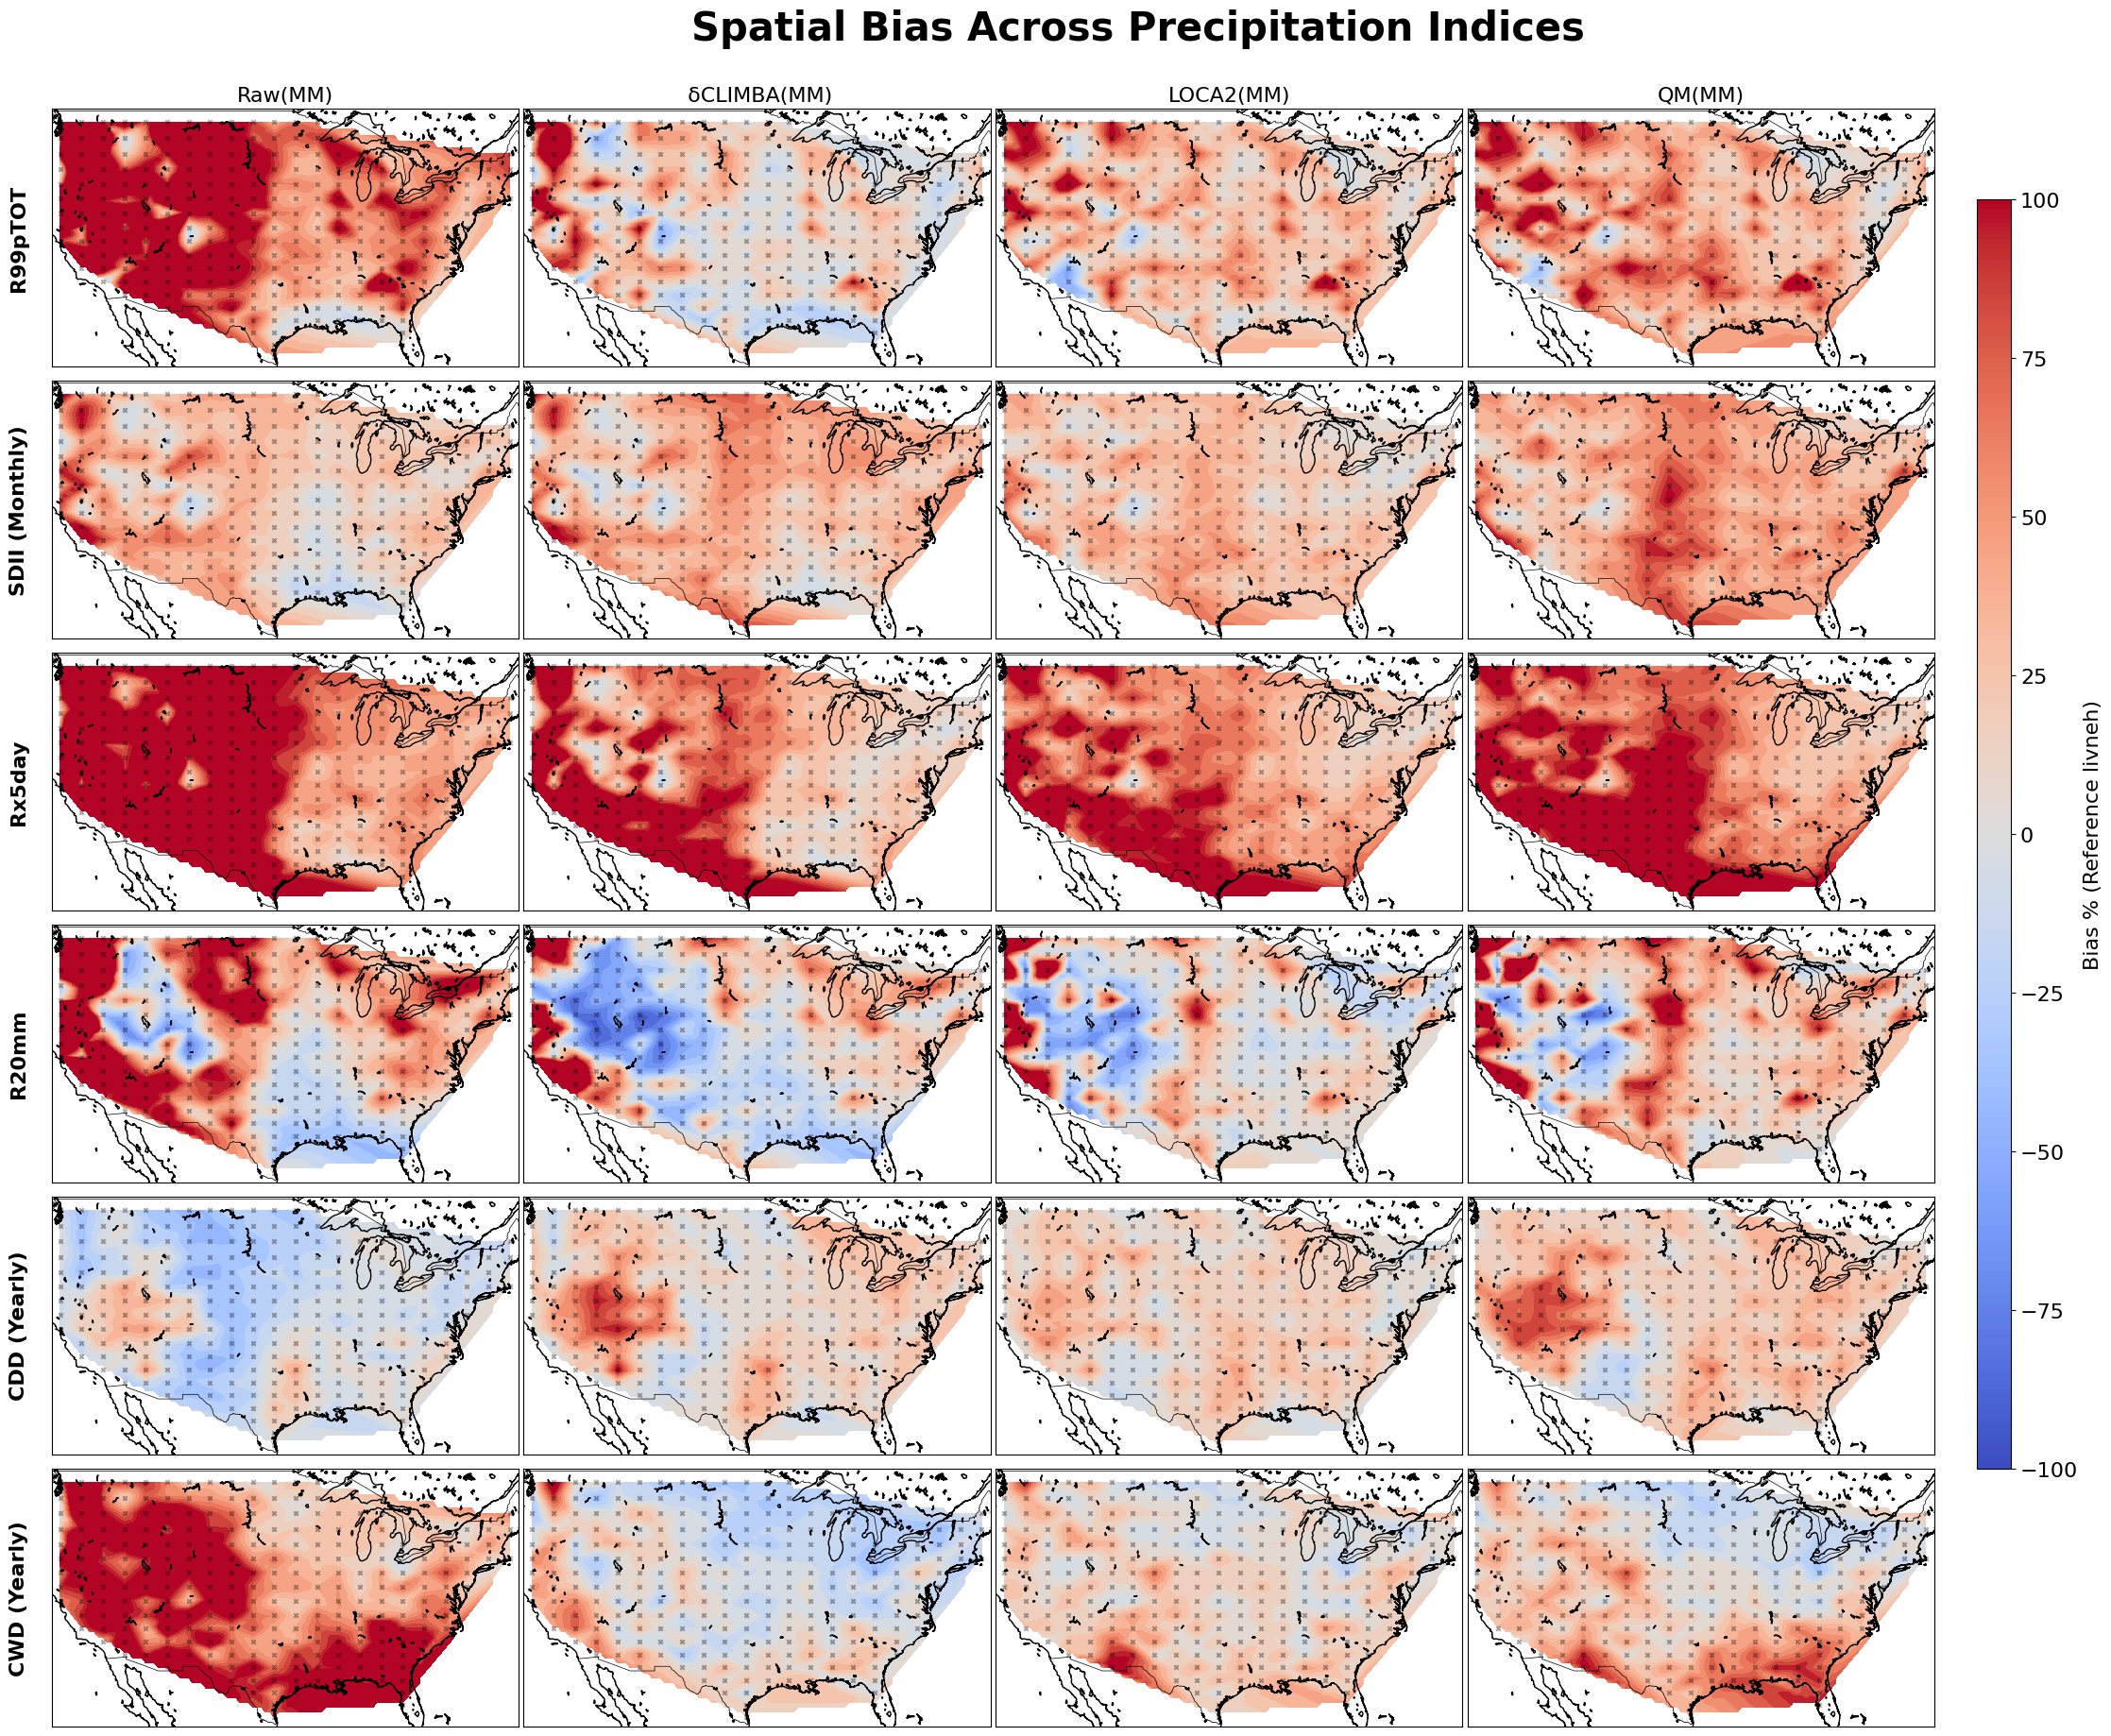

In [23]:
# analyze_indice = [['R95pTOT', 'SDII (Monthly)', 'Rx5day'], ['Rx1day', 'R10mm', 'R20mm'], ['SDII (Monthly)', 'CDD (Yearly)', 'CWD (Yearly)']]
analyze_indice = [['R99pTOT', 'SDII (Monthly)', 'Rx5day', 'R20mm', 'CDD (Yearly)', 'CWD (Yearly)']]

method_names = ['Raw(MM)',' δCLIMBA(MM)', 'LOCA2(MM)', 'QM(MM)']


for indice_list in analyze_indice:
    plot_spatial_bias(valid_coords=valid_coords[2],
                            bias_data_dict=filtered_bias_dict,
                            threshold_types=indice_list,
                            label=f"Bias % (Reference {models[2]['config']['ref']})",
                            method_names=method_names,
                            vmin=-100,
                            vmax=100,
                            cmap='coolwarm')

### Spatial Patterns

In [24]:
interp_coords = []
ensemble_coords = valid_coords[1]
for coords in valid_coords:
    interp_coords.append(find_nearest_indices(ensemble_coords, coords))

In [27]:
xt_nc_all = []
x_nc_all = []
y_nc_all = []
loca_nc_all = []
QM_nc_all = []
QDM_nc_all = []
ISIMIP_nc_all = []
ECDFM_nc_all = []
for i in range(len(models)):

    xt_nc = valid_crd.reconstruct_nc(models[i]['xt'], valid_coords[i], models[i]['x_time_np'], var='pr')
    xt_nc_all.append(xt_nc['pr'].values.mean(axis=0))

    x_nc = valid_crd.reconstruct_nc(models[i]['x'], valid_coords[i], models[i]['x_time_np'], var='pr')
    x_nc_all.append(x_nc['pr'].values.mean(axis=0))

    y_nc = valid_crd.reconstruct_nc(models[i]['y'], valid_coords[i], models[i]['x_time_np'], var='pr')
    y_nc_all.append(y_nc['pr'].values.mean(axis=0))

    loca_nc = valid_crd.reconstruct_nc(loca_all[i], valid_coords[i], models[i]['x_time_np'], var='pr')
    loca_nc_all.append(loca_nc['pr'].values.mean(axis=0))

    QDM_nc = valid_crd.reconstruct_nc(QDM_all[i], valid_coords[i], models[i]['x_time_np'], var='pr')
    QDM_nc_all.append(QDM_nc['pr'].values.mean(axis=0))

    ISIMIP_nc = valid_crd.reconstruct_nc(ISIMIP_all[i], valid_coords[i], models[i]['x_time_np'], var='pr')
    ISIMIP_nc_all.append(ISIMIP_nc['pr'].values.mean(axis=0))

    ECDFM_nc = valid_crd.reconstruct_nc(ECDFM_all[i], valid_coords[i], models[i]['x_time_np'], var='pr')
    ECDFM_nc_all.append(ECDFM_nc['pr'].values.mean(axis=0))

    QM_nc = valid_crd.reconstruct_nc(QM_all[i], valid_coords[i], models[i]['x_time_np'], var='pr')
    QM_nc_all.append(QM_nc['pr'].values.mean(axis=0))

/pscratch/sd/k/kas7897/dCLIMAD_BA/data/valid_crd.py:84: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_filtered = xr.Dataset(
/pscratch/sd/k/kas7897/dCLIMAD_BA/data/valid_crd.py:84: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting th

/pscratch/sd/k/kas7897/dCLIMAD_BA/data/valid_crd.py:84: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_filtered = xr.Dataset(
/pscratch/sd/k/kas7897/dCLIMAD_BA/data/valid_crd.py:84: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting th

In [28]:
def fractal_dimension(Z, threshold):
    """
    Calculate the fractal dimension of a 2D array Z using box-counting.
    Handles NaNs by replacing them with 0.
    """
    assert len(Z.shape) == 2
    Z = np.nan_to_num(Z, nan=0)  # Replace NaN with 0
    Z_bin = (Z < threshold)
    p = min(Z_bin.shape)
    # n = 2 ** np.floor(np.log(p) / np.log(2))
    n = int(np.log(p) / np.log(2))
    sizes = 2 ** np.arange(n, 1, -1)

    def boxcount(Z, k):
        S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
        return len(np.where((S > 0) & (S < k * k))[0])

    counts = [boxcount(Z_bin, size) for size in sizes]
    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]

# Example usage:
# Z = np.random.rand(64, 64)

## arrange numbers between 0 and 1
quantiles = np.arange(0, 1.00, 0.0001)

dim_xt_all = []
dim_x_all = []
dim_y_all = []
dim_loca_all = []
dim_QDM_all = []
dim_isimip_all = []
dim_ecdfm_all = []
dim_QM_all = []

for i in range(len(models)):
 
    dim_xt = []
    dim_x = []
    dim_y = []
    dim_loca = []
    dim_QDM = []
    dim_QM = []
    dim_isimip = []
    dim_ecdfm = []
    for q in quantiles:
        threshold_xt = np.nanquantile(xt_nc_all[i], q)
        dim_xt.append(fractal_dimension(xt_nc_all[i], threshold_xt))

        threshold_x = np.nanquantile(x_nc_all[i], q)
        dim_x.append(fractal_dimension(x_nc_all[i], threshold_x))

        threshold_y = np.nanquantile(y_nc_all[i], q)
        dim_y.append(fractal_dimension(y_nc_all[i], threshold_y))

        threshold_loca = np.nanquantile(loca_nc_all[i], q)
        dim_loca.append(fractal_dimension(loca_nc_all[i], threshold_loca))

        threshold_QDM = np.nanquantile(QDM_nc_all[i], q)
        dim_QDM.append(fractal_dimension(QDM_nc_all[i], threshold_QDM))

        threshold_isimip = np.nanquantile(ISIMIP_nc_all[i], q)
        dim_isimip.append(fractal_dimension(ISIMIP_nc_all[i], threshold_isimip))

        threshold_ecdfm = np.nanquantile(ECDFM_nc_all[i], q)
        dim_ecdfm.append(fractal_dimension(ECDFM_nc_all[i], threshold_ecdfm))

        threshold_QM = np.nanquantile(QM_nc_all[i], q)
        dim_QM.append(fractal_dimension(QM_nc_all[i], threshold_QM))

    dim_xt_all.append(dim_xt)
    dim_x_all.append(dim_x)
    dim_y_all.append(dim_y)
    dim_loca_all.append(dim_loca)
    dim_QDM_all.append(dim_QDM)
    dim_isimip_all.append(dim_isimip)
    dim_ecdfm_all.append(dim_ecdfm)
    dim_QM_all.append(dim_QM)

In [ ]:
dim_xt_arr = np.stack(dim_xt_all)  # shape: (n_models, n_quantiles)
dim_x_arr = np.stack(dim_x_all)  # shape: (n_models, n_quantiles)
dim_y_arr = np.stack(dim_y_all)  # shape: (n_models, n_quantiles)
dim_loca_arr = np.stack(dim_loca_all)  # shape: (n_models, n_quantiles)
dim_QDM_arr = np.stack(dim_QDM_all)  # shape: (n_models, n_quantiles)
dim_QM_arr = np.stack(dim_QM_all)  # shape: (n_models, n_quantiles)
dim_isimip_arr = np.stack(dim_isimip_all)  # shape: (n_models, n_quantiles)
dim_ecdfm_arr = np.stack(dim_ecdfm_all)  # shape: (



# Calculate mean, min, max across models for each latitude
dim_mean_xt = dim_xt_arr.mean(axis=0)
dim_min_xt = dim_xt_arr.min(axis=0)
dim_max_xt = dim_xt_arr.max(axis=0)

dim_mean_x = dim_x_arr.mean(axis=0)
dim_min_x = dim_x_arr.min(axis=0)
dim_max_x = dim_x_arr.max(axis=0)

dim_mean_y = dim_y_arr.mean(axis=0)
dim_min_y = dim_y_arr.min(axis=0)
dim_max_y = dim_y_arr.max(axis=0)

dim_mean_QDM = dim_QDM_arr.mean(axis=0)
dim_min_QDM = dim_QDM_arr.min(axis=0)
dim_max_QDM = dim_QDM_arr.max(axis=0)

dim_mean_QM = dim_QM_arr.mean(axis=0)
dim_min_QM = dim_QM_arr.min(axis=0)
dim_max_QM = dim_QM_arr.max(axis=0)

dim_mean_loca = dim_loca_arr.mean(axis=0)
dim_min_loca = dim_loca_arr.min(axis=0)
dim_max_loca = dim_loca_arr.max(axis=0)

dim_mean_isimip = dim_isimip_arr.mean(axis=0)
dim_min_isimip = dim_isimip_arr.min(axis=0)
dim_max_isimip = dim_isimip_arr.max(axis=0)

dim_mean_ecdfm = dim_ecdfm_arr.mean(axis=0)
dim_min_ecdfm = dim_ecdfm_arr.min(axis=0)
dim_max_ecdfm = dim_ecdfm_arr.max(axis=0)

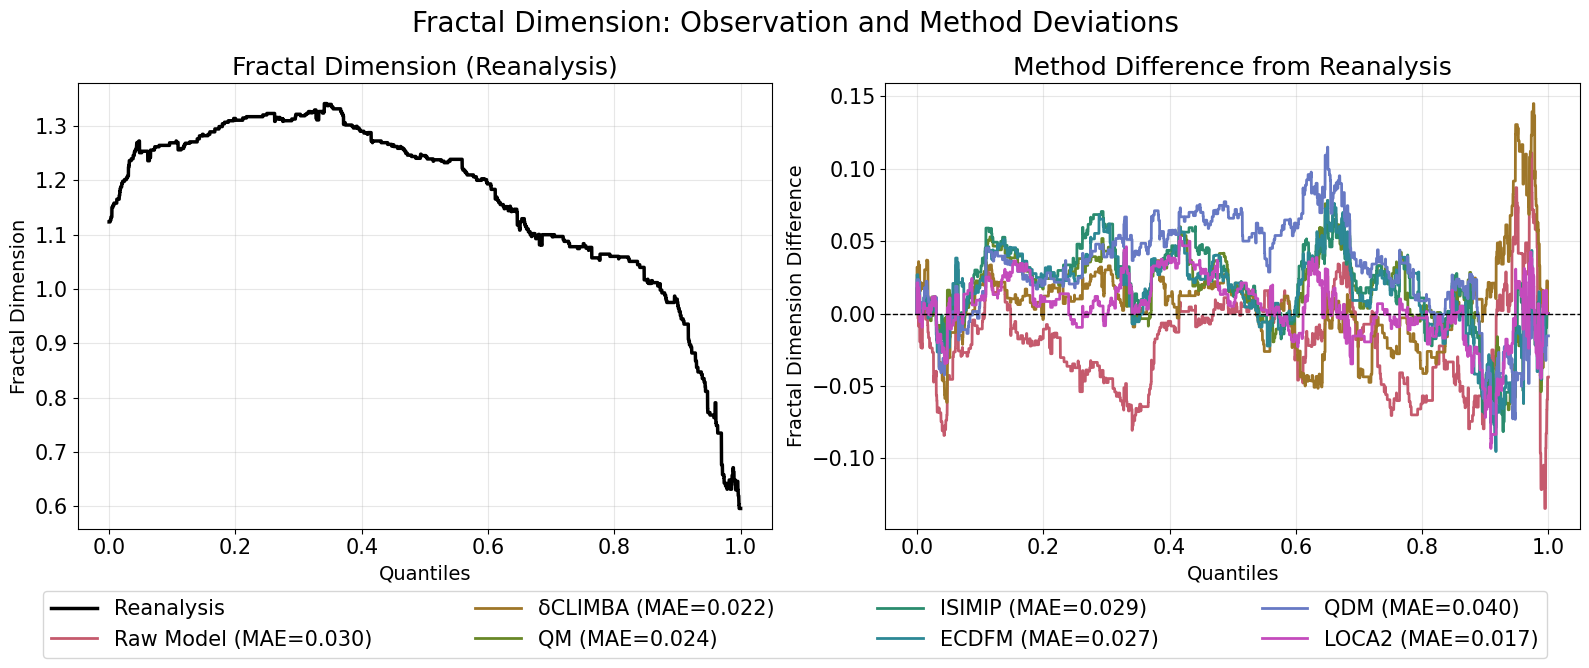

In [31]:
# Exact color reproduction from plot_violin_bias logic, with slightly darker colors
from matplotlib.lines import Line2D

violin_method_names = [
    "dCLIMBAD(MM)",
    "Quantile Mapping (MM)",
    "ISIMIP(MM)",
    "ECDFM(MM)",
    "Quantile Delta Mapping (MM)",
    "LOCA(MM)",
]

unique_methods = ["Raw"] + violin_method_names
color_palette = sns.color_palette("husl", len(unique_methods))
violin_color_mapping = {m: color_palette[i] for i, m in enumerate(unique_methods)}

# Darken colors a bit while preserving relative hues
darken_factor = 0.8
violin_color_mapping_dark = {
    k: tuple(np.clip(np.array(v) * darken_factor, 0, 1))
    for k, v in violin_color_mapping.items()
}

# Map fractal labels -> violin labels
fractal_to_violin = {
    "Raw Model": "Raw",
    "δCLIMBA": "dCLIMBAD(MM)",
    "QM": "Quantile Mapping (MM)",
    "ISIMIP": "ISIMIP(MM)",
    "ECDFM": "ECDFM(MM)",
    "QDM": "Quantile Delta Mapping (MM)",
    "LOCA2": "LOCA(MM)",
}

fig, (ax_obs, ax_diff) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Left panel: reanalysis
ax_obs.plot(quantiles, dim_mean_y, color="black", linewidth=2.5, label="Reanalysis")
ax_obs.set_title("Fractal Dimension (Reanalysis)", fontsize=18)
ax_obs.set_xlabel("Quantiles", fontsize=14)
ax_obs.set_ylabel("Fractal Dimension", fontsize=14)
ax_obs.tick_params(axis="both", labelsize=15)
ax_obs.grid(True, alpha=0.3)
# ax_obs.legend(fontsize=12)

# Right panel: differences from reanalysis (includes Quantile Mapping)
method_diffs = {
    "Raw Model": dim_mean_x - dim_mean_y,
    "δCLIMBA": dim_mean_xt - dim_mean_y,
    "QM": dim_mean_QM - dim_mean_y,
    "ISIMIP": dim_mean_isimip - dim_mean_y,
    "ECDFM": dim_mean_ecdfm - dim_mean_y,
    "QDM": dim_mean_QDM - dim_mean_y,
    "LOCA2": dim_mean_loca - dim_mean_y,
}

plot_order = ["Raw Model", "δCLIMBA", "QM", "ISIMIP", "ECDFM", "QDM", "LOCA2"]
for name in plot_order:
    diff = method_diffs[name]
    mae = np.nanmean(np.abs(diff))
    violin_key = fractal_to_violin[name]
    ax_diff.plot(
        quantiles,
        diff,
        color=violin_color_mapping_dark[violin_key],
        linewidth=2,
        label=f"{name} (MAE={mae:.3f})",
    )

ax_diff.axhline(0, color="black", linestyle="--", linewidth=1)
ax_diff.set_title("Method Difference from Reanalysis", fontsize=18)
ax_diff.set_xlabel("Quantiles", fontsize=14)
ax_diff.set_ylabel("Fractal Dimension Difference", fontsize=14)
ax_diff.tick_params(axis="both", labelsize=15)
ax_diff.grid(True, alpha=0.3)
# ax_diff.legend(fontsize=13)

obs_handle = Line2D([0], [0], color="black", linewidth=2.5, label="Reanalysis")

# 2) Reference black dashed line handle (same as ax_diff.axhline)
# ref_handle = Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Reference")

# 3) Method handles from right plot (already plotted)
method_handles, method_labels = ax_diff.get_legend_handles_labels()

all_handles = [obs_handle] + method_handles
all_labels = [h.get_label() for h in all_handles]

fig.legend(
    all_handles,
    all_labels,
    loc="lower left",
    bbox_to_anchor=(0.03, -0.10, 0.94, 0.16),  # x, y, width, height in figure coords
    mode="expand",                              # spreads entries across the box width
    ncol=4,                      # one long horizontal row
    frameon=True,
    fontsize=15,
    handlelength=2.2,
    columnspacing=1.1,
    borderaxespad=0.0
)

# Leave room at bottom for the shared legend box
plt.tight_layout(rect=[0, 0.16, 1, 1])


fig.suptitle("Fractal Dimension: Observation and Method Deviations", fontsize=20)
plt.tight_layout()
plt.savefig(f'{save_path}/fractalDim.png')

plt.show()